In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Principal Component Analysis

PCA is a machine learning method used in preprocessing large datasets in order to reduce dimensionality while preserving the most impactful features. It does this my minimizing issues of multicollinearity and overfitting by reducing the number of variables into *principal components*. It has appplications for *regression*, *pattern recognition*, and *signal processing*. There are variations of PCA as well, such as *principal component regression* and *kernal PCA*, that might be worth investigating in the future.

Principal components "are linear combinations of the original variables that have the maximum variance compared to other linear combinations. These components capture as much information from the original dataset as possible." There are 2 primary principal components used in PCA: the first principal component (PC1) and the second principal component (PC2).

**First principal component:**

**Second principal component:**

*scatterplot to visualize relationship between PC1 and PC2*


The basic steps for using PCA are:
- Explore raw data
- Standardize the data
- Calculate the covariance matrix
- Find the Principal Components
- Pick the top directions and transform the data



**Resources:**
- https://www.ibm.com/think/topics/principal-component-analysis

## Iris dataset

In [8]:
iris = pd.read_csv("data/iris.csv")

In [10]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


### Visualize the features

In [24]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


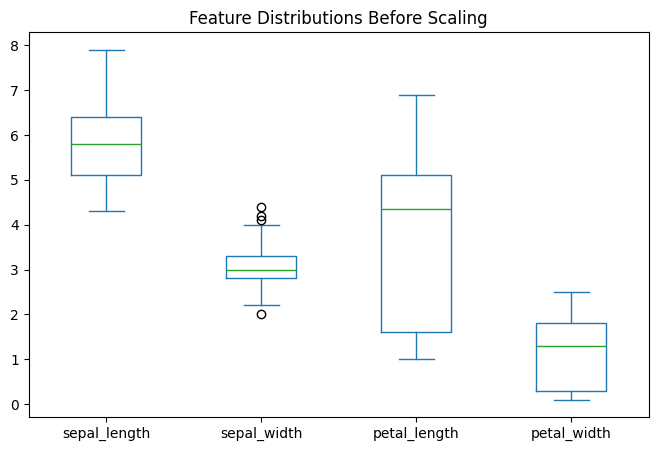

In [26]:
iris.drop(columns='species').plot(kind='box', figsize=(8, 5))
plt.title('Feature Distributions Before Scaling')
plt.show()

The boxplots illustrate the range of feature variation over all species.

In [34]:
iris_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [40]:
# calculate variance for each feature
for feat in iris[iris_features]:
    print(feat, iris[feat].var())

sepal_length 0.6856935123042505
sepal_width 0.18800402684563763
petal_length 3.1131794183445156
petal_width 0.5824143176733784


In [42]:
# iris.drop(columns='species').hist(figsize=(8, 6), bins=20)
# plt.suptitle('Feature Distributions')
# plt.tight_layout()
# plt.show()

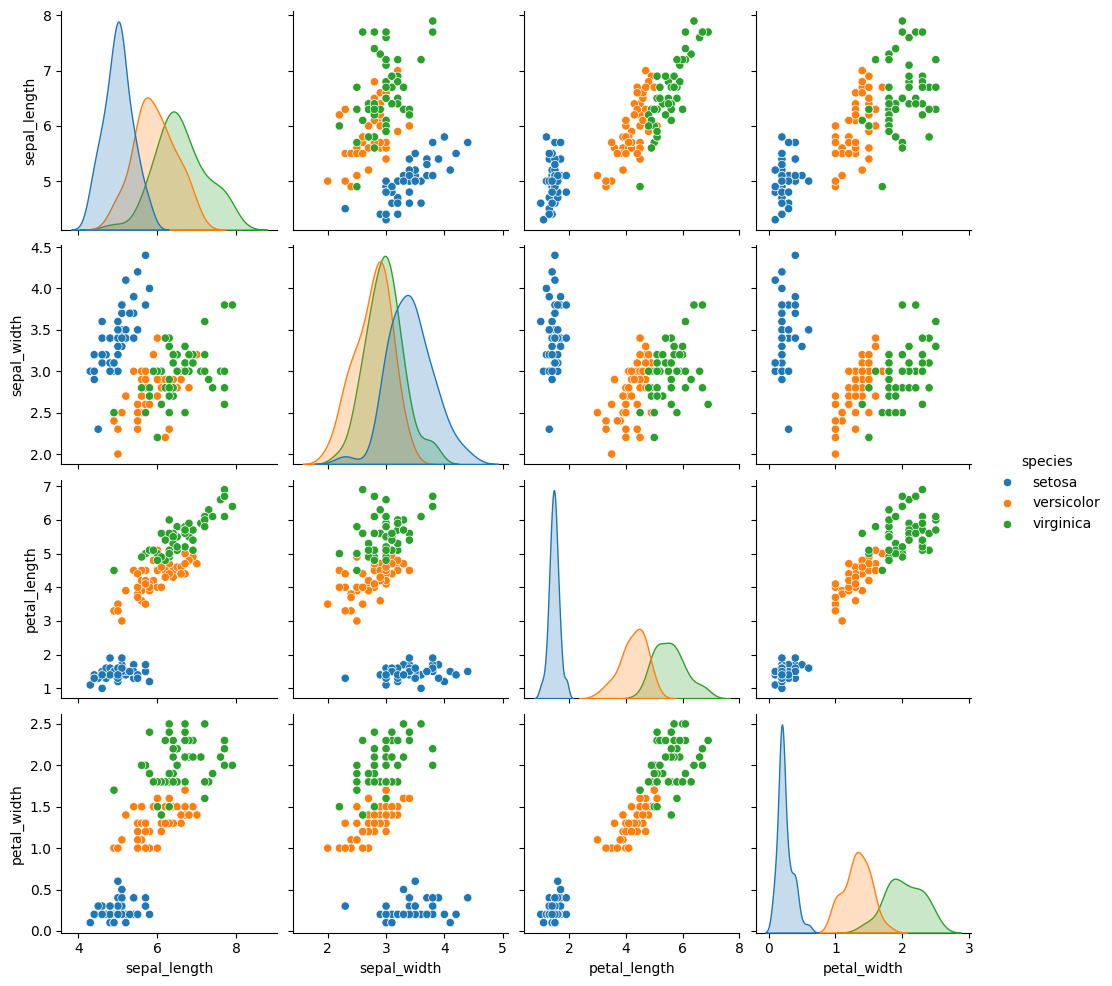

In [30]:
sns.pairplot(iris, hue='species')
plt.show()

What can we tell from this data? 
- petal_length has the largest variance, before scaling
- sepal_width is not a well separated feature
- petal_length and petal_width are bimodal
- setosa is the most well-separated of the three species
- petal_width and petal_length are highly correlated
- sepal_length and sepal_width are not highly correlated

Noticing the high correlations between features, the question becomes, do we need them all for anlysis, or will a reduced feature set capture what we need to do the analysis? 

*intuition behind orthogonality of features*

### Standardize the data

in order to compare features on a similar scale

In [46]:
X_iris = iris.drop('species', axis=1)
y_iris = iris['species']

scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

In [54]:
# verify that the means are centered around 0 and std = 1
pd.DataFrame(X_iris_scaled, columns=X_iris.columns).describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.44,-1.57,-1.44
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.12,0.34,0.13
75%,0.67,0.57,0.76,0.79
max,2.49,3.11,1.79,1.71


In [72]:
y_iris.values

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [74]:
X_iris_scaled_df = pd.DataFrame(X_iris_scaled, columns=X_iris.columns)
X_iris_scaled_df['species'] = y_iris.values
X_iris_scaled_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.900681,1.032057,-1.341272,-1.312977,setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,setosa
2,-1.385353,0.337848,-1.398138,-1.312977,setosa
3,-1.506521,0.106445,-1.284407,-1.312977,setosa
4,-1.021849,1.263460,-1.341272,-1.312977,setosa
...,...,...,...,...,...
145,1.038005,-0.124958,0.819624,1.447956,virginica
146,0.553333,-1.281972,0.705893,0.922064,virginica
147,0.795669,-0.124958,0.819624,1.053537,virginica
148,0.432165,0.800654,0.933356,1.447956,virginica


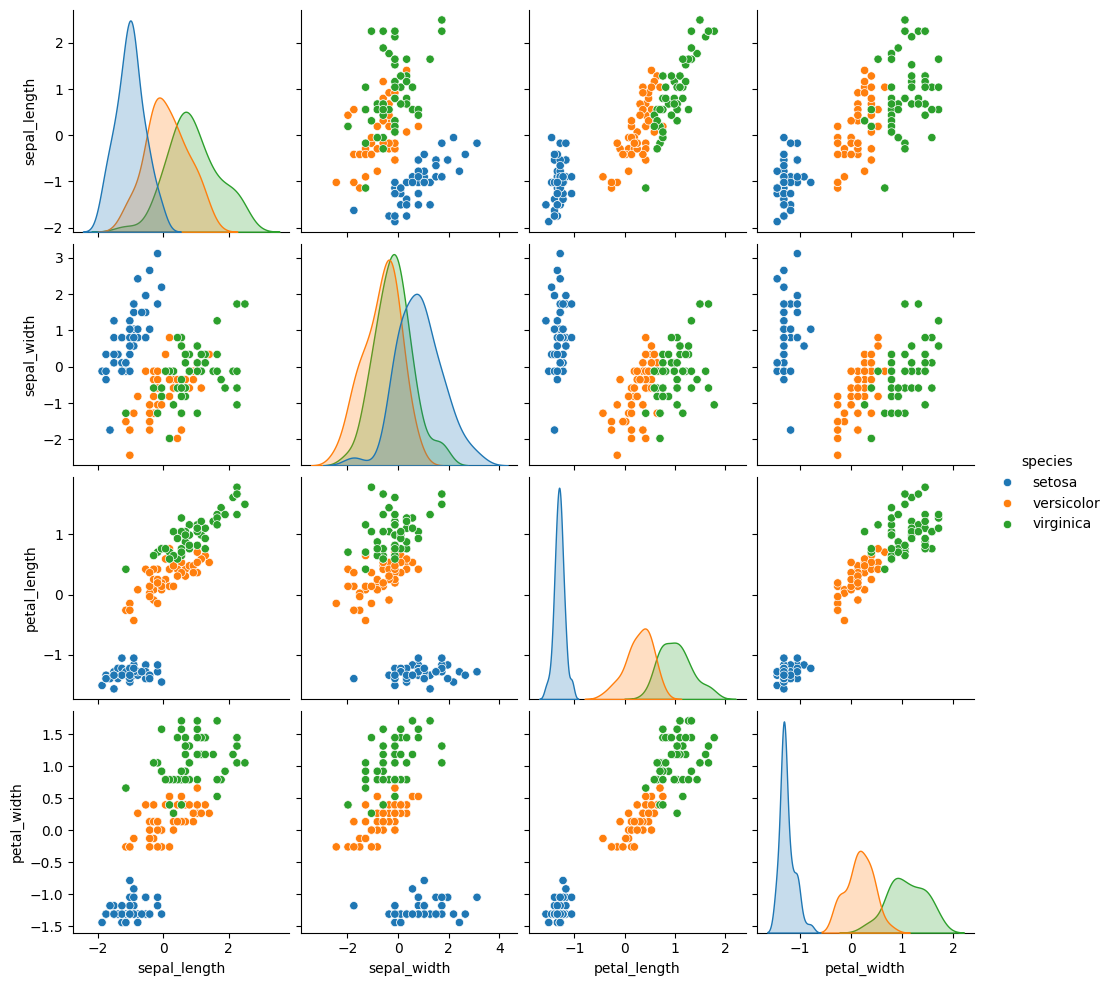

In [76]:
sns.pairplot(X_iris_scaled_df, hue='species')
plt.show()

The structure of the data is the same, but the scale of the axes has changed.

### Calculate the covariance matrix

*for classification analysis, would look at the confusion matrix.*

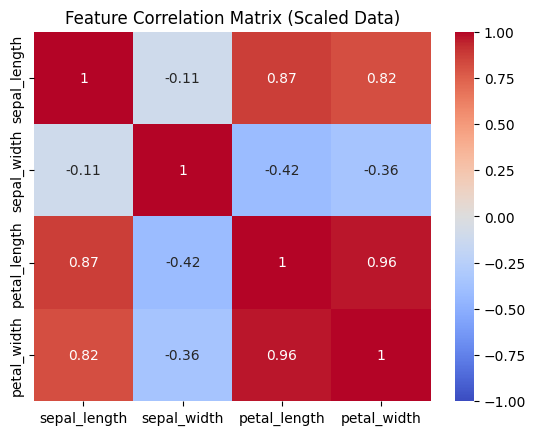

In [107]:
sns.heatmap(iris[iris_features].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix (Scaled Data)')
plt.show()

### *Eigenvalues and Eigenvectors*

In [110]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(eigenvalues / eigenvalues.sum())  # should match explained_variance_ratio_

[0.72770452 0.23030523 0.03683832 0.00515193]


The principal components are the eigenvectors of the covariance matrix. 

The eignevalues represent the amount of variance in each component. 

"Ranking the eigenvectors by eigenvalue identifies the order of principal components."

### Principal Components

For the purpose of EDA and understanding how PCA restructures the data, there is no need to split the data into train-test datasets.

If using as a preprocessing step before applying a classifier, would need to split the data for training and evaluation.

In [258]:
from sklearn.decomposition import PCA

pca = PCA()

# fit on scaled data
X_iris_pca = pca.fit_transform(X_iris_scaled)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[0.72770452 0.23030523 0.03683832 0.00515193]
[0.72770452 0.95800975 0.99484807 1.        ]


This output corresponds to the new principal components created with PCA. Each new component is a weigthed combination of the original features.

PC1 and PC2 explain 95.8% of the variance. PC3 and PC4 contribute very little and can be dropped without losing a lot of information.

### Loadings

To see the **loadings**, or the breakdown of how much each feature contributes to each principal component:

In [86]:
pd.DataFrame(
    pca.components_,
    columns=X_iris.columns,
    index=['PC1', 'PC2', 'PC3', 'PC4']
).round(2)

,sepal_length,sepal_width,petal_length,petal_width
PC1,0.52,-0.26,0.58,0.57
PC2,0.37,0.93,0.02,0.07
PC3,0.72,-0.24,-0.14,-0.63
PC4,-0.26,0.12,0.80,-0.52


PC1 is composed of petal features and sepal length. The dominant component describes flower size. Flowers that have a high PC1 score are larger than flowers with a small PC2 score.

PC2 primarily describes sepal proportions and is dominated by sepal width. A high PC2 score means a wide sepal. A low PC2 score means a more narrow sepal.

PC3 has a high positive loading on sepal length and a strong negative loading on petal width. This component captures characteristics of long sepals to narrow petals, with smaller contributions from sepal width and petal length. A high PC3 score indicates a flower with long sepal and narrow petal. A low PC3 score indicates a flower with a short sepal and wide petal.

PC4 is dominated by the contrast between petal length and petal width. This component describes the aspect ratio of the flower, with a high PC4 score indicating a flower has a long, narrow petal, and a low PC4 score indicating the flower has a short, wide petal structure. This is the least significant component, capturing the smallest remaining variance. 

In [275]:
iris_loadings = pd.DataFrame(
    pca.components_.T,
    index=X_iris.columns,
    columns=[f'PC{i+1}' for i in range(4)]
)

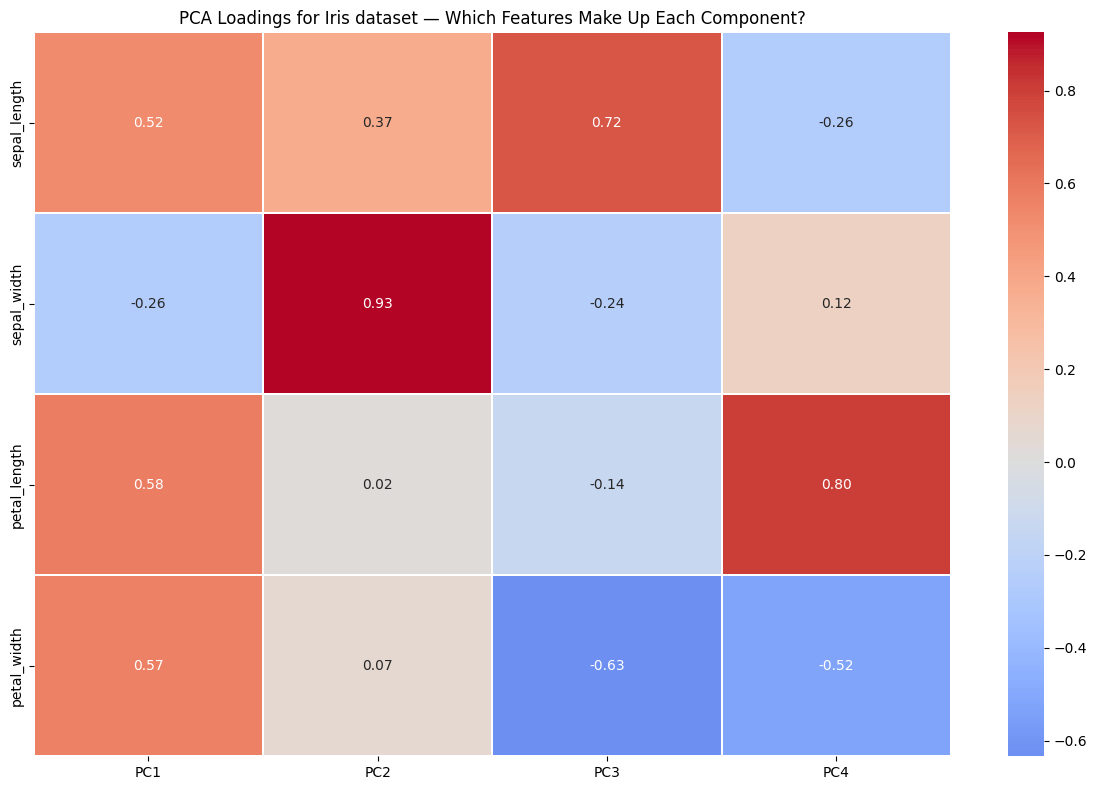

In [277]:
plt.figure(figsize=(12, 8))
sns.heatmap(iris_loadings[['PC1','PC2','PC3','PC4']],
            cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3)
plt.title('PCA Loadings for Iris dataset — Which Features Make Up Each Component?')
plt.tight_layout()
plt.show()

### Pick the top directions and transform the data

- Visualize top components with a scree plot
- Refit PCA with the top components
- Visualize the result

#### Scree plot

Use a scree plot to visualize how components contribute to the total variation in the dataset. Reminder: components are NOT features, but weighted combinations of features. 

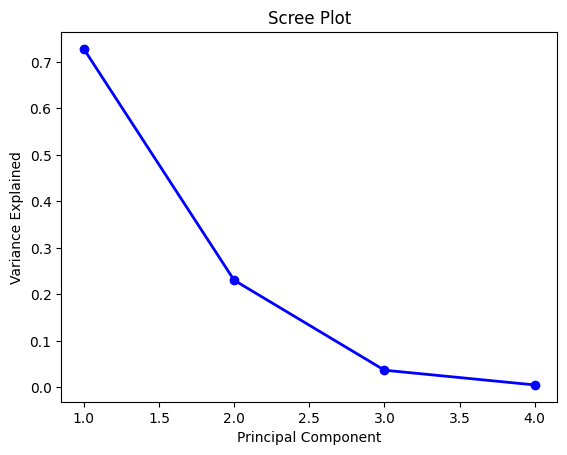

In [113]:
pc_values = np.arange(pca.n_components_) + 1
plt.plot(pc_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

The x-axis represents the principal component, and the y-axis represents the percentage of total variance explained by each compononent. The elbow (harder to see with so few components, but is at PC2) shows where adding more components is not adding much to the variance.  

In [282]:
# fit PCA on reduced components (2 components) 
pca2 = PCA(n_components=2)
X_iris_pca2 = pca2.fit_transform(X_iris_scaled)

In [284]:
print(X_iris_pca.shape)
print(X_iris_pca2.shape)

(150, 4)
(150, 2)


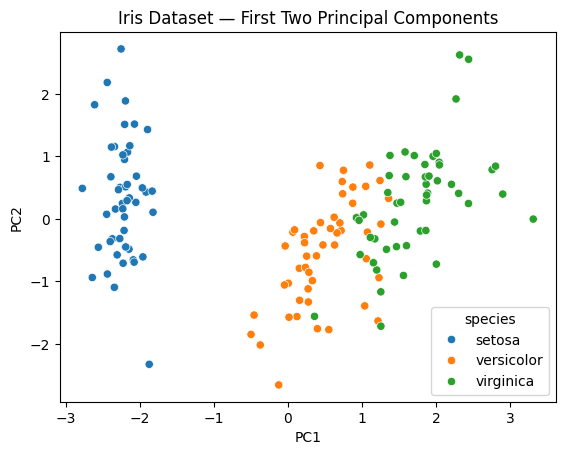

In [125]:
# visualize the result
iris_pca_df = pd.DataFrame(X_iris_pca2, columns=['PC1', 'PC2'])
iris_pca_df['species'] = y_iris.values

sns.scatterplot(data=iris_pca_df, x='PC1', y='PC2', hue='species')
plt.title('Iris Dataset — First Two Principal Components')
plt.show()

**Conclusions:**

PC1 captures characteristics of flower size and PC2 captures characteristics of sepal width. Along PC1, setosa is completely separated from versicolor and virginica (with PC1 ranging from -3 to -1.5). Versicolor and Virginica are mostly separated along PC1, with central tendencies, but still demonstrate some overlap. While they are not cleanly separated, there is partial discrimination between these species of iris. 

PC2 captures sepal width variation within a species, not between species and is not a unique identifier for flower species. PC2 (sepal width) does not separate clearly by species and has the least variation within the versicolor flowers.

PC1 performs the best at discriminating between species. PC1 and PC2 alone are enought to distinguish setosa from the other species but is not quite enough to separate versicolor from virginica. 

# Breast Cancer Wisconsin dataset

In [170]:
cancer = pd.read_csv("data/breast_cancer_wisconsin.csv", index_col=0).reset_index()
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [189]:
cancer.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

The data consists of 10 features (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension), each with an associated mean, standard error ("_se"), and "worst" feature.

In [201]:
cancer[['radius_mean', 'radius_se', 'radius_worst']]

,radius_mean,radius_se,radius_worst
0,17.99,1.0950,25.380
1,20.57,0.5435,24.990
2,19.69,0.7456,23.570
3,11.42,0.4956,14.910
4,20.29,0.7572,22.540
...,...,...,...
564,21.56,1.1760,25.450
565,20.13,0.7655,23.690
566,16.60,0.4564,18.980
567,20.60,0.7260,25.740


In [172]:
cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


We can see how the scales vary widely among features.

In [174]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [178]:
# drop Unnamed and unique id
cancer = cancer.drop(columns=['Unnamed: 32', 'id'])
cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


This leaves 30 numerical features in the dataset.

### Intuition behind using PCA 

Where does the intuition behind using PCA for this dataset arise? First, consider feature correlations.

### Feature correlations 

In [184]:
cancer_features = cancer.drop(columns=['diagnosis'], errors='ignore')
corr = cancer_features.corr()

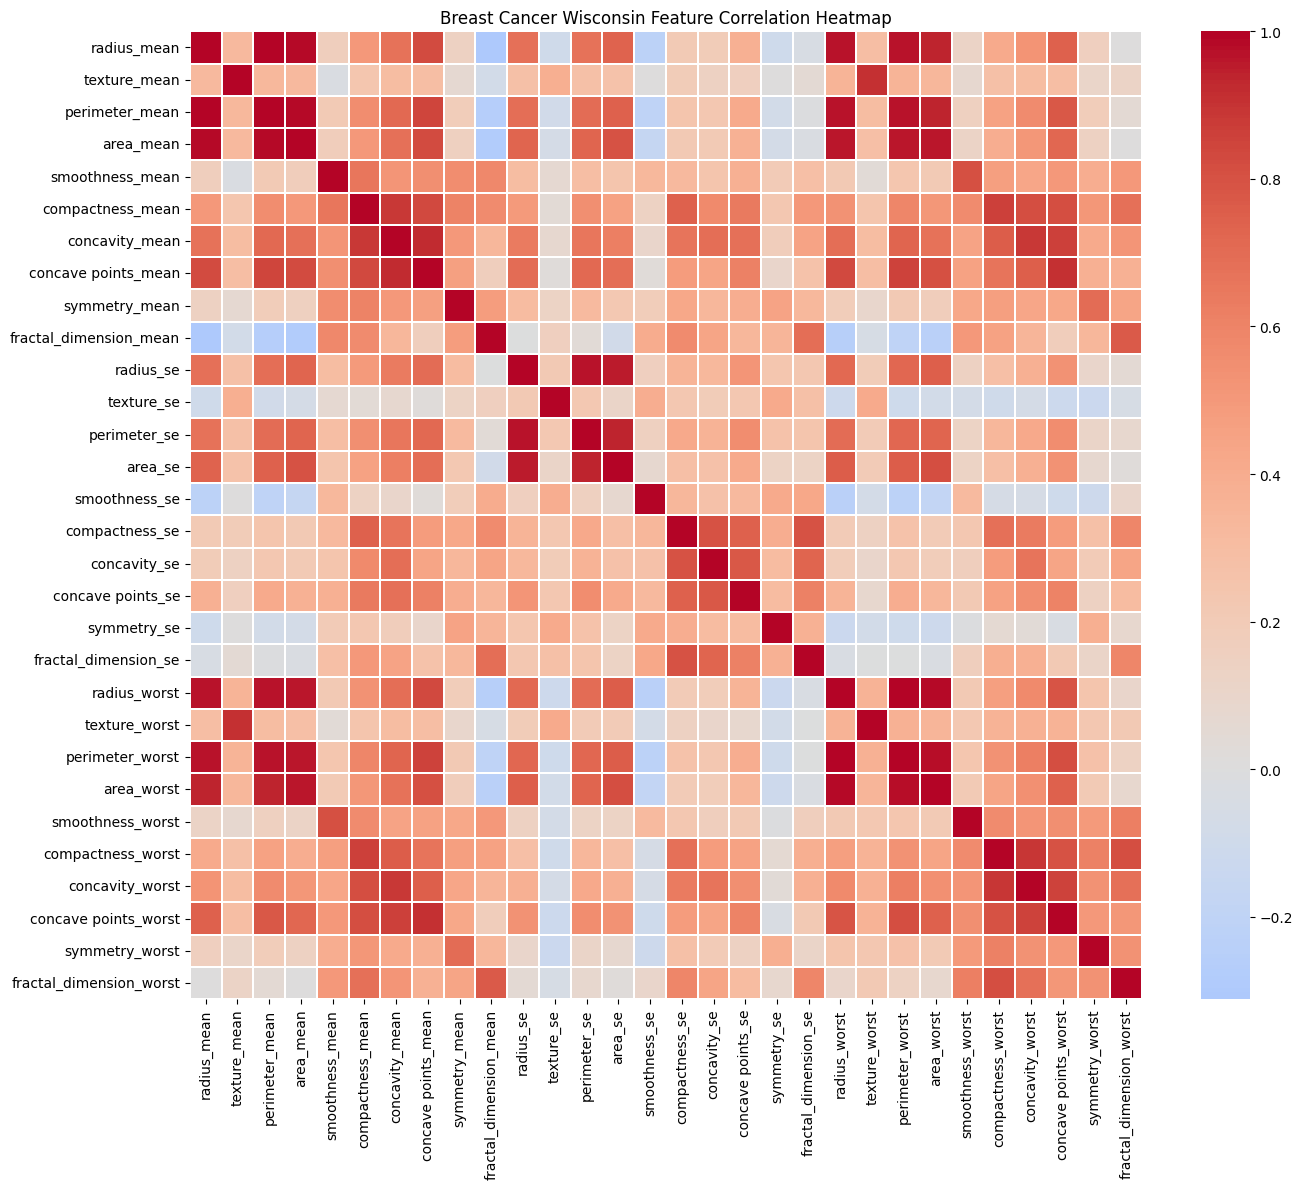

In [187]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Breast Cancer Wisconsin Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

There is a lot of correlation between features. This indicates that a technique for reducing multicollinearity (dimensionality) will be useful. 

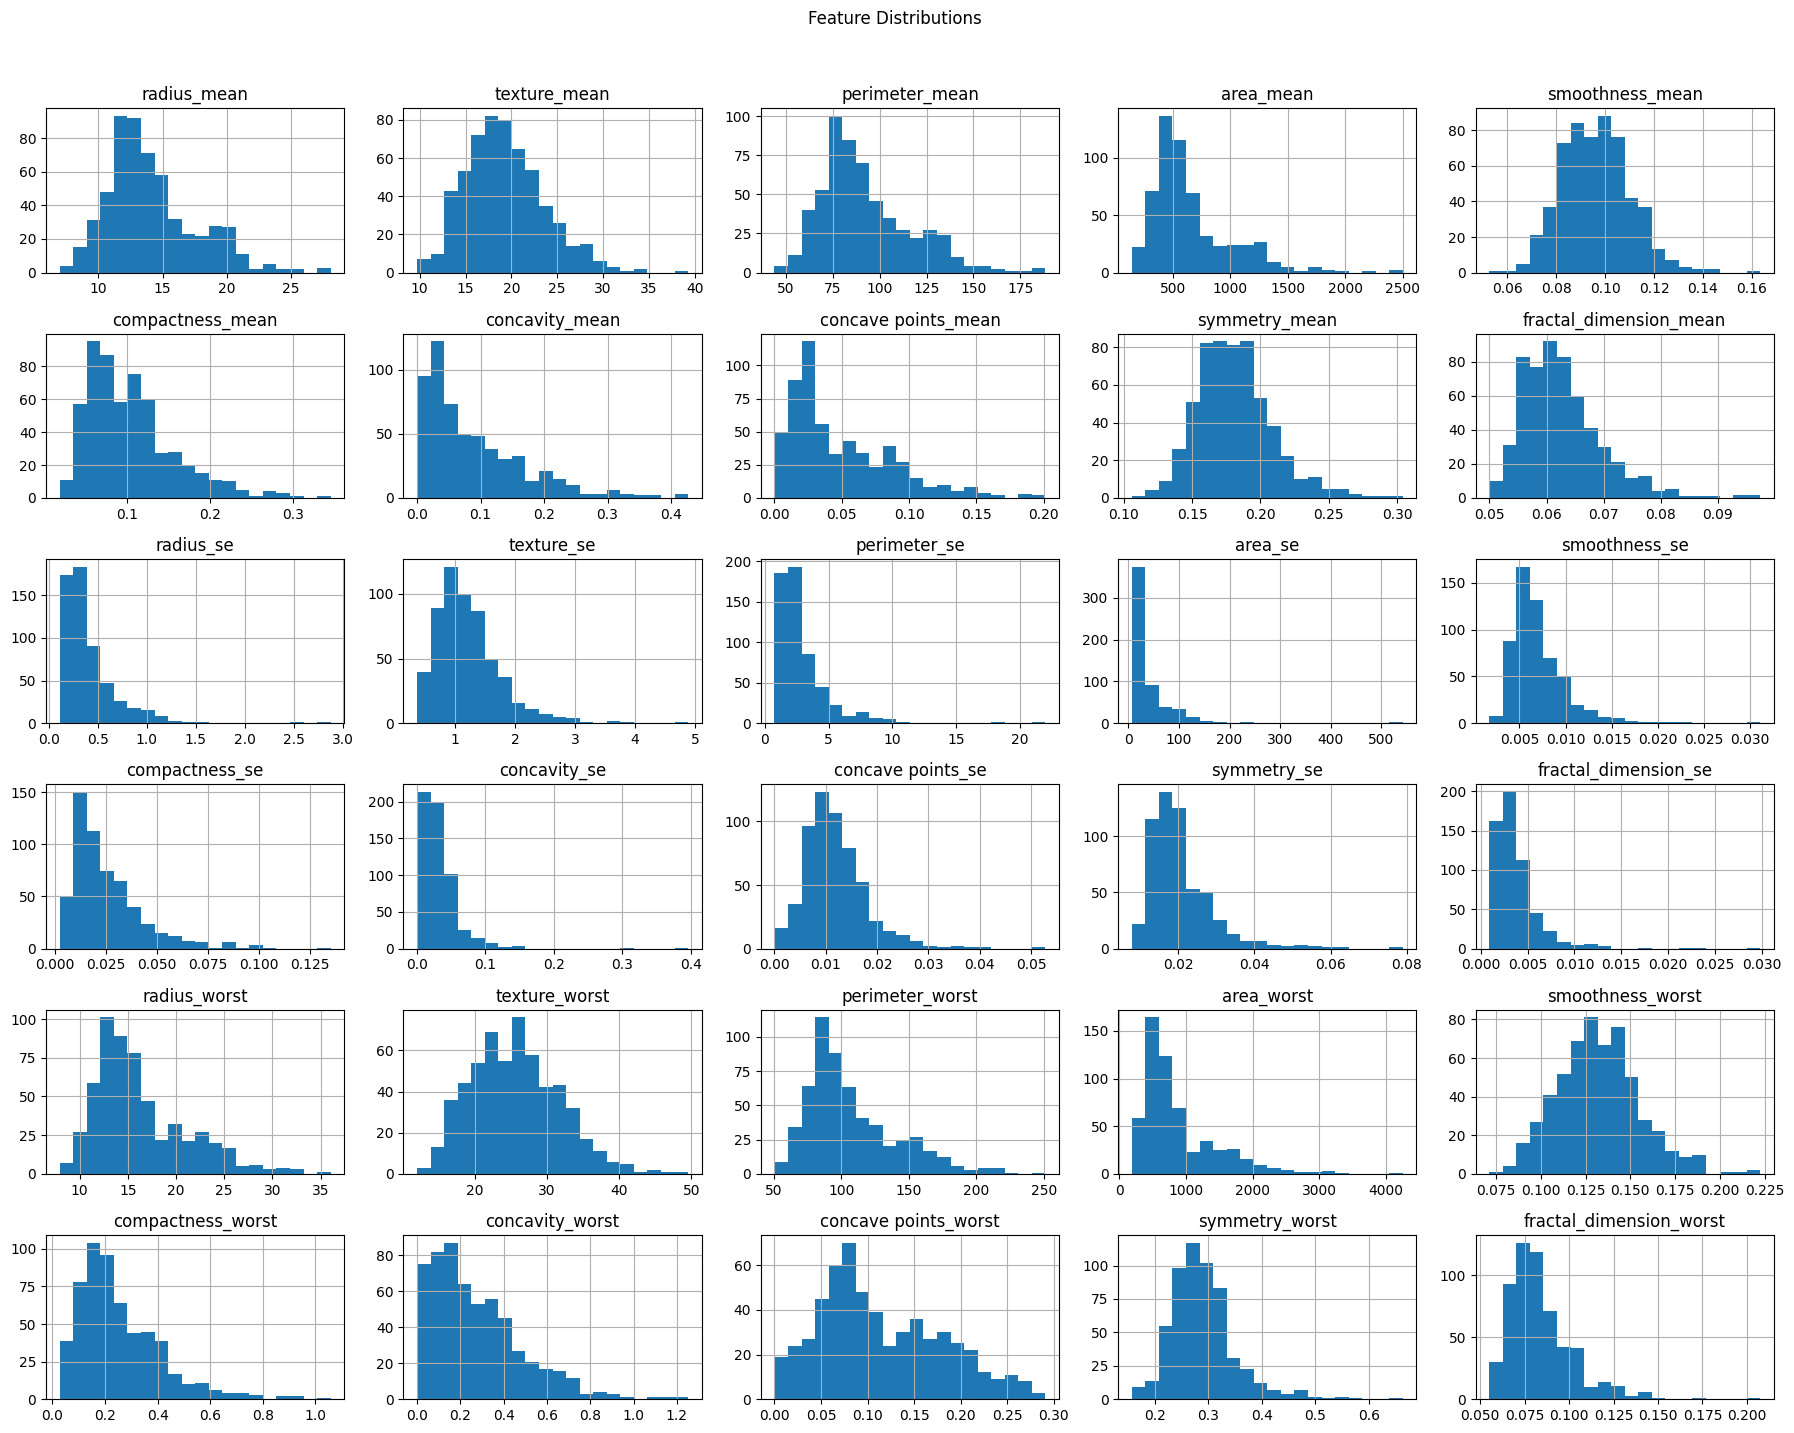

In [206]:
cancer_features.hist(figsize=(18, 14), bins=20)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

Visualizing the features illustrates the different scales at work (x-axis), indicating a need for scaling before proceeding with PCA. 

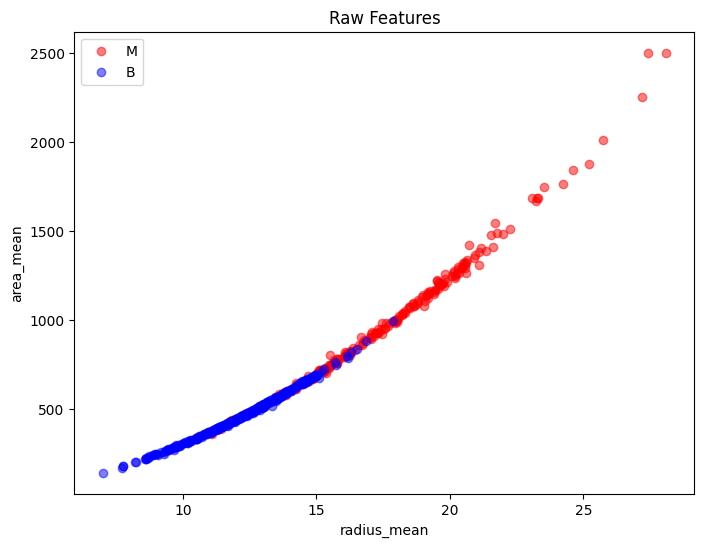

In [288]:
# visualize two of the highly correlated features
plt.figure(figsize=(8,6))
for label, color in [('M', 'red'), ('B', 'blue')]:
    mask = cancer['diagnosis'] == label
    plt.scatter(cancer.loc[mask, 'radius_mean'], cancer.loc[mask, 'area_mean'],
                alpha=0.5, label=label, color=color)
plt.xlabel('radius_mean'); plt.ylabel('area_mean')
plt.legend(); plt.title('Raw Features')
plt.show()

In [219]:
print(cancer[['radius_mean', 'perimeter_mean', 'area_mean']].corr())

                radius_mean  perimeter_mean  area_mean
radius_mean        1.000000        0.997855   0.987357
perimeter_mean     0.997855        1.000000   0.986507
area_mean          0.987357        0.986507   1.000000


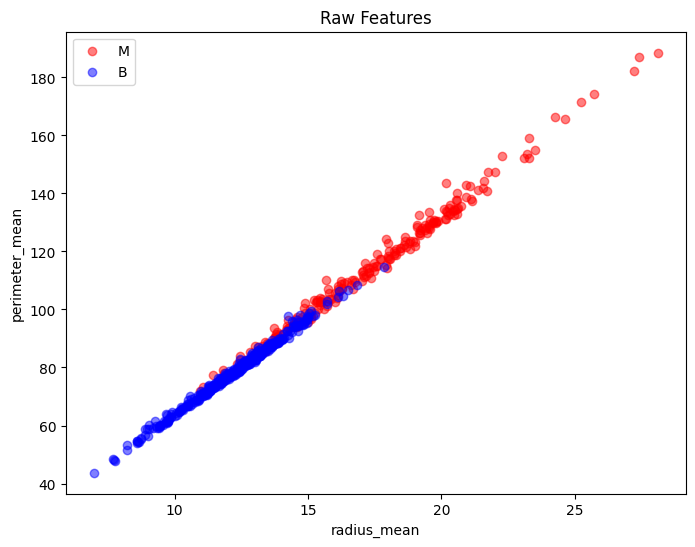

In [290]:
# visualize two of the highly correlated features
plt.figure(figsize=(8,6))
for label, color in [('M', 'red'), ('B', 'blue')]:
    mask = cancer['diagnosis'] == label
    plt.scatter(cancer.loc[mask, 'radius_mean'], cancer.loc[mask, 'perimeter_mean'],
                alpha=0.5, label=label, color=color)
plt.xlabel('radius_mean'); plt.ylabel('perimeter_mean')
plt.legend(); plt.title('Raw Features')
plt.show()

Near perfect correlation. While obvious here, knowing the mean radius gives us the information we need about the mean perimeter and mean area.

These features are essentially one feature (ie, highly correlated to one another). This is where PCA could reduce them to a single feature without losing information, and could do so across all 30 features, not just these 3 features. 

**Steps for PCA:** 

- scale the features
- apply PCA algorithm
- consider loadings
- choose top components to keep
- refit PCA and evaluate

In [294]:
# scale the data
X_cancer = cancer_features.values
scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)

In [382]:
# fit PCA to scaled data
pca3 = PCA()
cancer_pca3 = pca3.fit(X_cancer_scaled)

In [384]:
pca3

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [364]:
print(pca3.explained_variance_ratio_)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [366]:
print(pca3.explained_variance_ratio_.cumsum())

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


In [368]:
# consider the loadings
cancer_loadings = pd.DataFrame(
    pca3.components_,
    columns=cancer_features.columns
).round(2)

# reset index
cancer_loadings.index = [f'PC{i}' for i in range(1, len(cancer_loadings) + 1)]

cancer_loadings

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
PC1,0.22,0.10,0.23,0.22,0.14,0.24,0.26,0.26,0.14,0.06,...,0.23,0.10,0.24,0.22,0.13,0.21,0.23,0.25,0.12,0.13
PC2,-0.23,-0.06,-0.22,-0.23,0.19,0.15,0.06,-0.03,0.19,0.37,...,-0.22,-0.05,-0.20,-0.22,0.17,0.14,0.10,-0.01,0.14,0.28
PC3,-0.01,0.06,-0.01,0.03,-0.10,-0.07,0.00,-0.03,-0.04,-0.02,...,-0.05,-0.04,-0.05,-0.01,-0.26,-0.24,-0.17,-0.17,-0.27,-0.23
PC4,-0.04,0.60,-0.04,-0.05,-0.16,-0.03,-0.02,-0.07,-0.07,-0.05,...,-0.02,0.63,-0.01,-0.03,-0.02,0.09,0.07,-0.01,0.04,0.08
PC5,-0.04,0.05,-0.04,-0.01,0.37,-0.01,-0.09,0.04,0.31,0.04,...,0.00,0.09,-0.01,0.03,0.32,-0.12,-0.19,-0.04,0.24,-0.09
PC6,0.02,-0.03,0.02,-0.00,-0.29,-0.01,-0.01,-0.05,0.36,-0.12,...,-0.00,-0.05,0.01,-0.03,-0.37,0.05,0.03,-0.03,0.50,-0.08
PC7,-0.12,0.01,-0.11,-0.05,-0.14,0.03,-0.11,-0.15,-0.09,0.30,...,-0.01,0.01,-0.00,0.07,-0.11,0.14,-0.06,-0.17,-0.02,0.37
PC8,-0.01,0.13,-0.02,0.03,-0.29,-0.15,-0.07,-0.15,-0.23,-0.18,...,0.04,0.04,0.03,0.08,0.21,0.08,0.07,-0.04,0.23,0.05
PC9,-0.22,0.11,-0.22,-0.20,0.01,-0.17,0.04,-0.11,0.26,-0.12,...,-0.11,0.10,-0.11,-0.08,0.11,-0.10,0.16,0.06,0.06,-0.13
PC10,0.10,0.24,0.09,0.07,-0.07,0.01,-0.14,0.01,0.57,0.08,...,0.08,0.03,0.05,0.07,-0.13,-0.17,-0.31,-0.08,-0.03,0.01


In [370]:
# visualize loadings for top 4 components
cancer_loadings = pd.DataFrame(
    pca3.components_.T,
    index=cancer_features.columns,
    columns=[f'PC{i+1}' for i in range(30)]
)

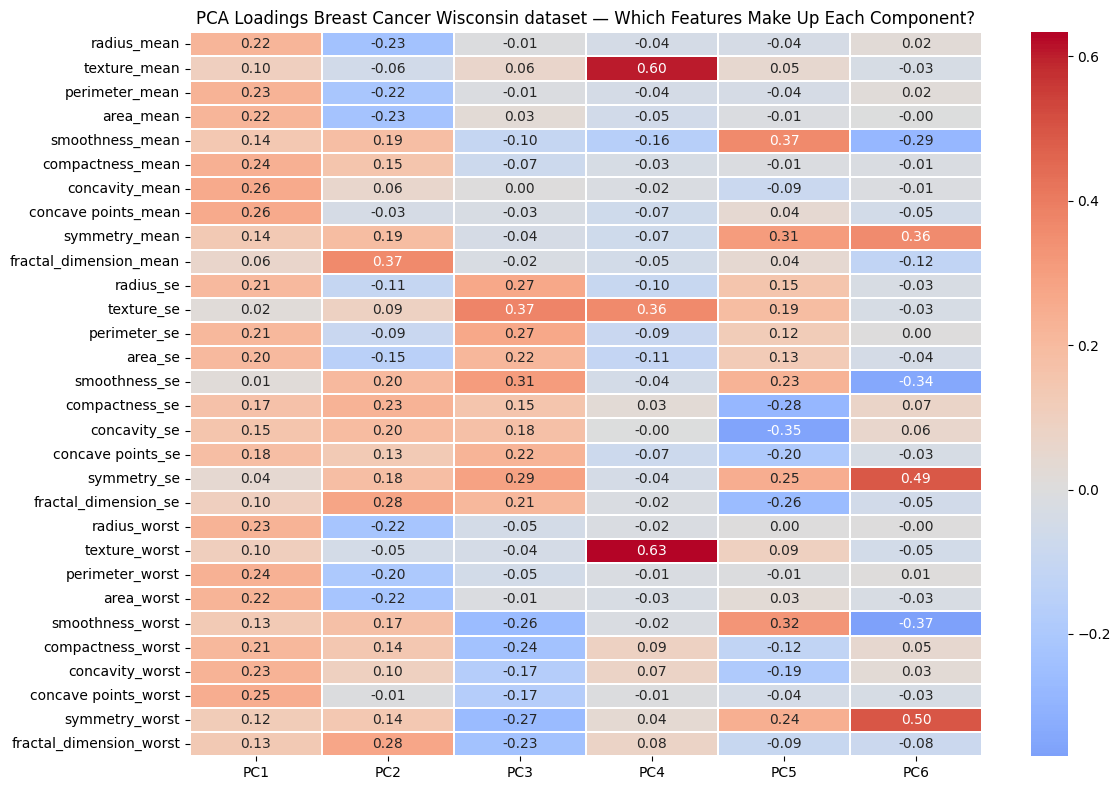

In [342]:
plt.figure(figsize=(12, 8))
sns.heatmap(cancer_loadings[['PC1','PC2','PC3','PC4', 'PC5', 'PC6']],
            cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3)
plt.title('PCA Loadings Breast Cancer Wisconsin dataset — Which Features Make Up Each Component?')
plt.tight_layout()
plt.show()

PC1 captures the overall tumor size and irregularity. It is the broadest component with nearly all size related features loading positively and uniformly. 

Fractal dimension is a measure of boundary irregularity. PC2 captures the boundary characterisitcs of tumors, with a high PC2 score indicating a tumor with an irregular boundary and small size characteristics, while a how PC2 score indicating a tumor with a less irreular boundary and large size characterisits. This component is a measure of a different kind of abnormality. 

PC3 captures measurement variability (the _se group). This component component loads positively with a high inconsistency of measurements across the tumor. It loads negatively with the family of _worst features. *Not sure what this means...* 

PC4 component overwhelmingly captures characteristics of texture in a tumor, independent of size and shape. 

Something else to notice. The mean, standard error, and worst feature groups tend to load together, suggesting that they are different statistics measuring similar things.

PC1 dominates, accounting for 44% of the variance in the data. 

PC4 is clinically interesting, isolating texture alone as significant and independent of other features.  

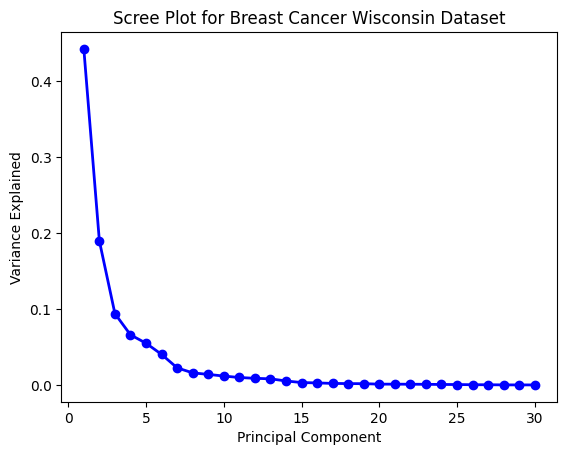

In [372]:
# create a scree plot
pc_cancer_values = np.arange(pca3.n_components_) + 1
plt.plot(pc_cancer_values, pca3.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot for Breast Cancer Wisconsin Dataset')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

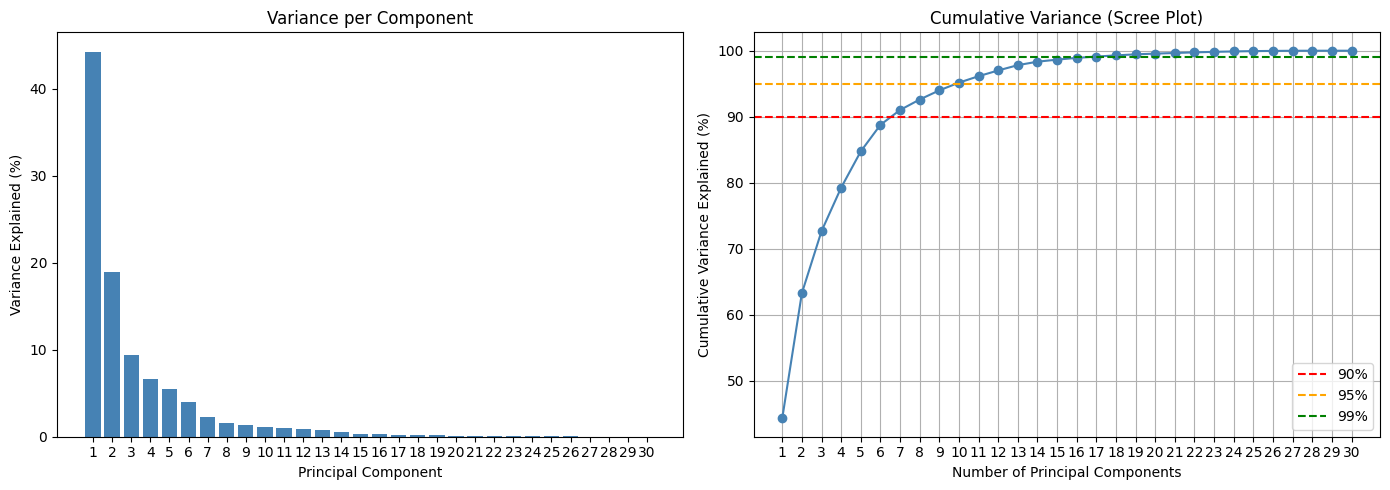

PC01: 44.3%  cumulative: 44.3%
PC02: 19.0%  cumulative: 63.2%
PC03: 9.4%  cumulative: 72.6%
PC04: 6.6%  cumulative: 79.2%
PC05: 5.5%  cumulative: 84.7%
PC06: 4.0%  cumulative: 88.8%
PC07: 2.3%  cumulative: 91.0%
PC08: 1.6%  cumulative: 92.6%
PC09: 1.4%  cumulative: 94.0%
PC10: 1.2%  cumulative: 95.2%
PC11: 1.0%  cumulative: 96.1%
PC12: 0.9%  cumulative: 97.0%
PC13: 0.8%  cumulative: 97.8%
PC14: 0.5%  cumulative: 98.3%
PC15: 0.3%  cumulative: 98.6%
PC16: 0.3%  cumulative: 98.9%
PC17: 0.2%  cumulative: 99.1%
PC18: 0.2%  cumulative: 99.3%
PC19: 0.2%  cumulative: 99.5%
PC20: 0.1%  cumulative: 99.6%
PC21: 0.1%  cumulative: 99.7%
PC22: 0.1%  cumulative: 99.7%
PC23: 0.1%  cumulative: 99.8%
PC24: 0.1%  cumulative: 99.9%
PC25: 0.1%  cumulative: 99.9%
PC26: 0.0%  cumulative: 100.0%
PC27: 0.0%  cumulative: 100.0%
PC28: 0.0%  cumulative: 100.0%
PC29: 0.0%  cumulative: 100.0%
PC30: 0.0%  cumulative: 100.0%


In [374]:
# another way to visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# calculate the cumulative variance as a percentage 
cumvar_cancer = pca3.explained_variance_ratio_.cumsum()*100

# left: individual variance per component
ax1.bar(range(1, 31), pca3.explained_variance_ratio_ * 100, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Variance per Component')
ax1.set_xticks(range(1, 31))

# right: cumulative variance
ax2.plot(range(1, 31), cumvar_cancer, marker='o', color='steelblue')
ax2.axhline(90, color='red',    linestyle='--', label='90%')
ax2.axhline(95, color='orange', linestyle='--', label='95%')
ax2.axhline(99, color='green',  linestyle='--', label='99%')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance (Scree Plot)')
ax2.set_xticks(range(1, 31))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print the numbers
for i, (ind, cum) in enumerate(zip(pca3.explained_variance_ratio_*100, cumvar_cancer)):
    print(f"PC{i+1:02d}: {ind:.1f}%  cumulative: {cum:.1f}%")

If we want to retain components that describe 90% of the explained variance, we would hang onto 7 components. To get at 95% of the explained variance, we would retain 10 components, whereas 17 of 30 components would explain 99% of the variance in the data. 

In [359]:
# refit the PCA on the top 10 components
pca4 = PCA(n_components=10)
cancer_pca4 = pca4.fit_transform(X_cancer_scaled)

In [388]:
print(cancer_pca4.shape)

(569, 10)


In [396]:
# visualize the result
cancer_pca_df = pd.DataFrame(cancer_pca4, columns=[
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'
])

In [402]:
cancer_pca_df['diagnosis'] = cancer['diagnosis'].values

In [404]:
cancer_pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,diagnosis
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,-0.398407,-0.157118,-0.877402,M
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0.240988,-0.711905,1.106995,M
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0.097374,0.024066,0.454275,M
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,1.059565,-1.405440,-1.116975,M
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0.636376,-0.263805,0.377704,M
...,...,...,...,...,...,...,...,...,...,...,...
564,6.439315,-3.576817,2.459487,-1.177314,0.074824,-2.375193,-0.596130,-0.035471,0.987929,0.256989,M
565,3.793382,-3.584048,2.088476,2.506028,0.510723,-0.246710,-0.716326,-1.113360,-0.105207,-0.108632,M
566,1.256179,-1.902297,0.562731,2.089227,-1.809991,-0.534447,-0.192758,0.341887,0.393917,0.520877,M
567,10.374794,1.672010,-1.877029,2.356031,0.033742,0.567936,0.223082,-0.280239,-0.542035,-0.089296,M


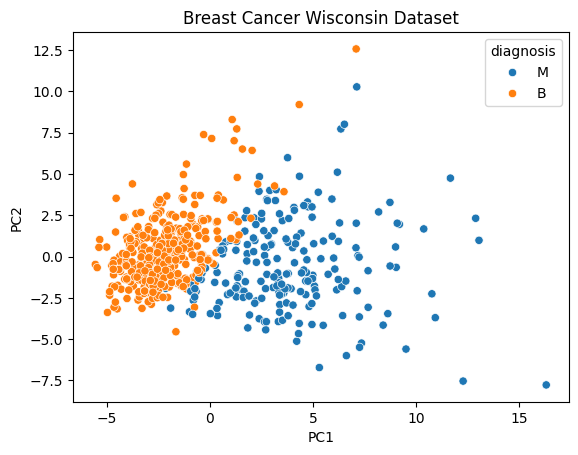

In [416]:
sns.scatterplot(data=cancer_pca_df, x='PC1', y='PC2', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

This plot has the best separation and confirms that overall tumor size (PC1) is the best differentiator between malignant and benign tumors. PC2 (boundary characteristics) is not a difscrimnating feature, sharing a simlar spread in characteristics between M and B tumor types. 

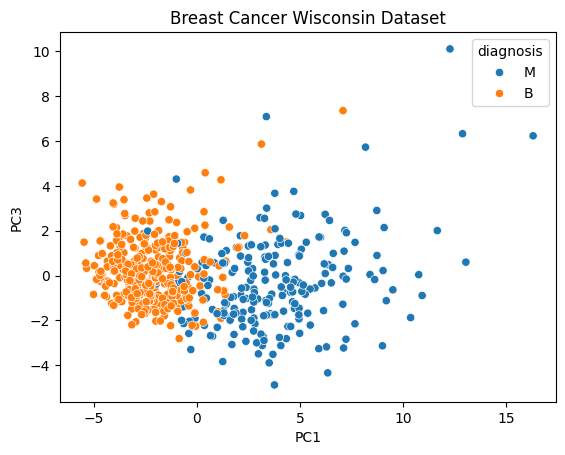

In [418]:
sns.scatterplot(data=cancer_pca_df, x='PC1', y='PC3', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

Simlarly, PC1 is doing all the work here, with PC3 (measurement variability) not differentiating much between tumor types. 

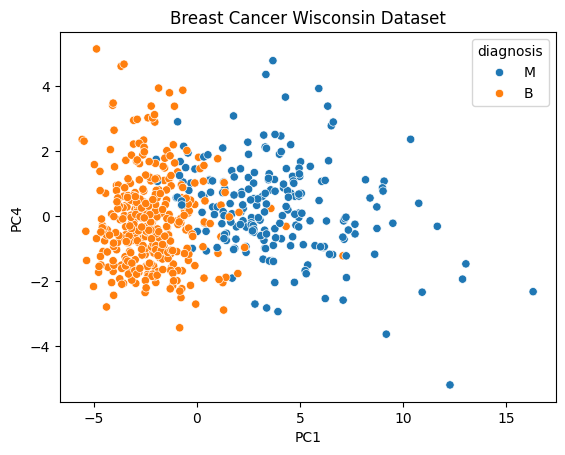

In [420]:
sns.scatterplot(data=cancer_pca_df, x='PC1', y='PC4', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

PC1 separates between tumor type, PC4 (texture) does not. 

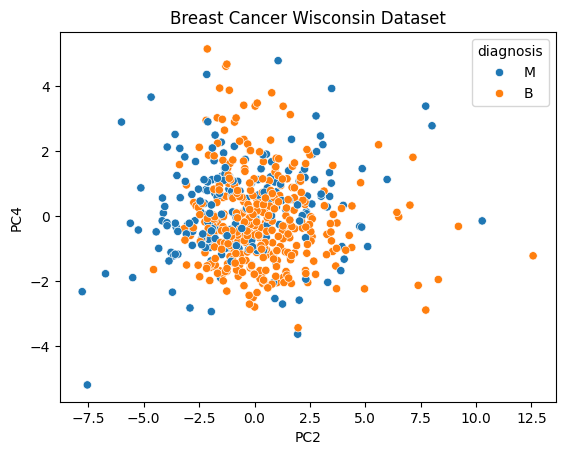

In [422]:
sns.scatterplot(data=cancer_pca_df, x='PC2', y='PC4', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

No useful separation here and between the following components. 

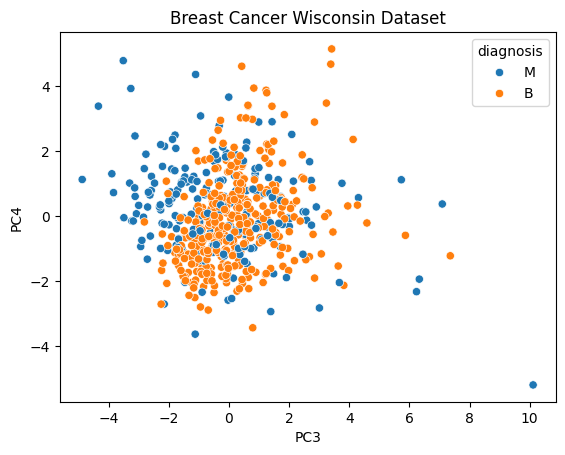

In [424]:
sns.scatterplot(data=cancer_pca_df, x='PC3', y='PC4', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

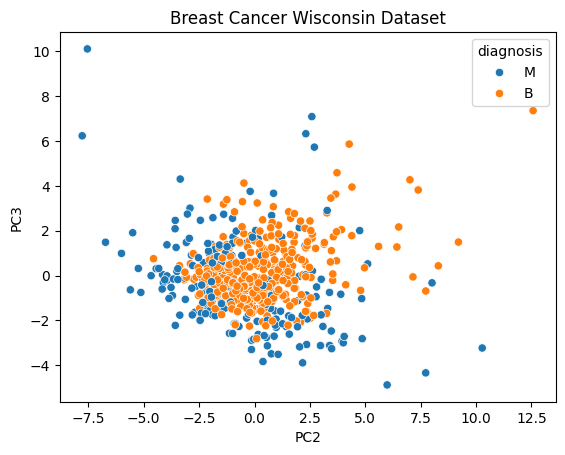

In [426]:
sns.scatterplot(data=cancer_pca_df, x='PC2', y='PC3', hue='diagnosis')
plt.title('Breast Cancer Wisconsin Dataset')
plt.show()

This all confirms that PC1, the overall size features, are capturing the most important information needed to differntiate between malignant and benign tumors. 